# power_scan: Detection & Recovery Limits

Synthetic injection-recovery tests sweeping over:
- **Amplitude / noise σ** — peak signal relative to per-pixel noise (log-spaced, 20 steps, 0.1–10)
- **Period** — sinusoidal period from near-Nyquist to near the observation window

Each cell runs **N_TRIALS** independent noise realisations of a Gaussian-PSF point source
in white noise, then fits a **log-logistic sigmoid** to the detection fraction curve to
extract the 50 % threshold and transition steepness.

---
**Theoretical background.**  
For a pure sinusoid of amplitude *A* observed *N* times in white noise *σ*, the
Lomb-Scargle power at the true frequency scales as
$$z \approx \frac{N A^2}{4\sigma^2}$$
so the `power_norm` (z normalised by the image median/std) grows as $(A/\sigma)^2$.  
Detection requires `power_norm > snr_search_lim` (default 10), giving a theoretical
50 % amplitude threshold
$$\left(\frac{A}{\sigma}\right)_{50} \approx \sqrt{\frac{4\,z_{\rm thr}}{N}}$$
independent of period (for periods well inside the window).  
With *N*=1000 and $z_{\rm thr}$≈10 this gives A/σ ≈ 0.20 — we test whether the empirical
threshold agrees.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import warnings
import io
from contextlib import redirect_stdout
from scipy.optimize import curve_fit
from scipy.special import expit          # numerically stable sigmoid

import power_scan as ps

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 10

## Synthetic data helpers

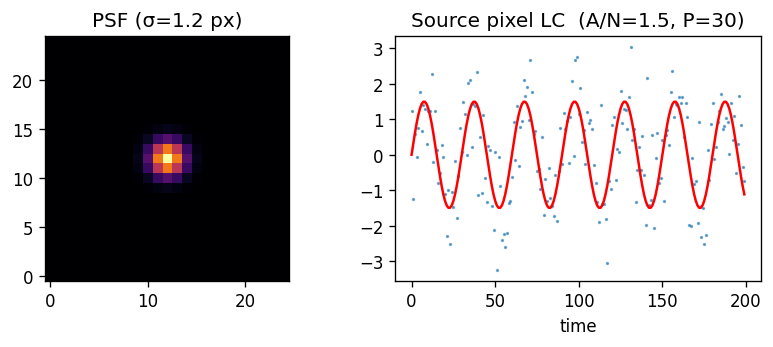

In [2]:
def make_gaussian_psf(size=25, x0=12, y0=12, sigma=1.2):
    """2-D Gaussian PSF, normalised to unit peak."""
    y, x = np.mgrid[0:size, 0:size]
    psf  = np.exp(-((x - x0)**2 + (y - y0)**2) / (2 * sigma**2))
    return psf / psf.max()


def make_scene(n_frames, period, amplitude, noise_sigma=1.0,
               image_size=25, source_x=12, source_y=12,
               psf_sigma=1.2, seed=None):
    """
    Synthetic image cube (n_frames, image_size, image_size).

    Variable source:  flux(t) = amplitude * sin(2π t / period)  [zero DC component]
    Background:       i.i.d. Gaussian noise, std = noise_sigma
    PSF:              2-D Gaussian with sigma = psf_sigma pixels
    """
    rng  = np.random.default_rng(seed)
    time = np.arange(n_frames, dtype=float)
    psf  = make_gaussian_psf(image_size, source_x, source_y, psf_sigma)

    signal      = amplitude * np.sin(2 * np.pi / period * time)
    source_cube = signal[:, np.newaxis, np.newaxis] * psf[np.newaxis, :, :]
    noise       = rng.normal(0.0, noise_sigma, (n_frames, image_size, image_size))
    return time, source_cube + noise


def find_best_match(sources, true_x, true_y, true_period,
                    pos_tol=2.0, period_rtol=0.15):
    """
    Return (recovered, rec_period, dx, dy) for the best positional + period match.
    dx / dy are signed centroid offsets (detected - true).
    """
    if sources is None or len(sources) == 0:
        return False, None, None, None
    for _, row in sources.iterrows():
        dx = float(row['xcentroid']) - true_x
        dy = float(row['ycentroid']) - true_y
        dr = np.hypot(dx, dy)
        dp = abs(row['period'] - true_period) / true_period
        if dr <= pos_tol and dp <= period_rtol:
            return True, float(row['period']), dx, dy
    return False, None, None, None


# ── sanity check ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
psf = make_gaussian_psf()
axes[0].imshow(psf, origin='lower', cmap='inferno')
axes[0].set_title('PSF (σ=1.2 px)')

t_demo, s_demo = make_scene(200, 30, 1.5, seed=0)
axes[1].plot(t_demo, s_demo[:, 12, 12], '.', ms=2, alpha=0.6)
axes[1].plot(t_demo, 1.5 * np.sin(2*np.pi/30*t_demo), 'r-', lw=1.5)
axes[1].set_title('Source pixel LC  (A/N=1.5, P=30)')
axes[1].set_xlabel('time')
plt.tight_layout()
plt.show()

## Grid parameters

| Parameter | Value | Notes |
|---|---|---|
| N_FRAMES | 1000 | cadence = 1 → Nyquist period ≈ 2; max period ≈ 666 |
| IMAGE_SIZE | 25×25 | one source at (12,12) |
| N_TRIALS | 5 | noise realisations per cell |
| Amplitudes | 20 log-steps, 0.1–10 ×σ | resolves the transition region |
| Periods | 7 values, 5–300 | spans Nyquist to 45% of window |

In [3]:
N_FRAMES    = 1000
NOISE_SIGMA = 1.0
IMAGE_SIZE  = 25
SOURCE_X    = 12
SOURCE_Y    = 12
N_TRIALS    = 5

PERIODS    = [5, 10, 20, 50, 100, 200, 300]

# 20 log-spaced amplitudes: denser near the transition
AMP_OVER_N = np.round(np.logspace(-1, 1, 20), 4).tolist()

# Theoretical 50% threshold: A50 = sigma * sqrt(4 * z_thr / N)
Z_THR    = 10          # snr_search_lim default
A50_THEORY = NOISE_SIGMA * np.sqrt(4 * Z_THR / N_FRAMES)

n_total = len(AMP_OVER_N) * len(PERIODS) * N_TRIALS
print(f"{len(AMP_OVER_N)} amplitudes × {len(PERIODS)} periods × {N_TRIALS} trials = {n_total} runs")
print(f"Amplitude grid: {[round(a,3) for a in AMP_OVER_N]}")
print(f"Theoretical A50 (N={N_FRAMES}, z_thr={Z_THR}): {A50_THEORY:.3f} × σ")

20 amplitudes × 7 periods × 5 trials = 700 runs
Amplitude grid: [0.1, 0.127, 0.162, 0.207, 0.264, 0.336, 0.428, 0.546, 0.695, 0.886, 1.129, 1.438, 1.833, 2.336, 2.976, 3.793, 4.833, 6.159, 7.848, 10.0]
Theoretical A50 (N=1000, z_thr=10): 0.200 × σ


## Run injection-recovery grid

Results are stored **per trial** so we can compute position scatter as well as detection fractions.

In [4]:
trial_rows  = []   # one row per individual trial
run_idx     = 0

# Early stopping: track consecutive full-detection amplitude steps per period.
# Once a period has det_frac == 1.0 for STOP_STREAK consecutive steps, assume
# all higher amplitudes will also detect and skip that period.
STOP_STREAK = 2
consec_full = {per: 0 for per in PERIODS}   # consecutive full-det count per period
saturated   = {per: False for per in PERIODS}

for a_over_n in AMP_OVER_N:
    amplitude = a_over_n * NOISE_SIGMA

    # If every period is saturated, nothing left to test
    if all(saturated.values()):
        print(f"All periods saturated at A/N={a_over_n:.3f} — stopping early.")
        break

    for period in PERIODS:
        if saturated[period]:
            # Fill the results table so the grid stays rectangular
            for trial in range(N_TRIALS):
                trial_rows.append(dict(
                    amp_over_noise = a_over_n,
                    period         = period,
                    trial          = trial,
                    recovered      = 1,       # assumed detected
                    rec_period     = float(period),
                    dx             = 0.0,
                    dy             = 0.0,
                    dr             = 0.0,
                ))
            run_idx += N_TRIALS
            print(f"[{run_idx:4d}/{n_total}]  A/N={a_over_n:6.3f}  P={period:4d}  "
                  f"det=1.00 ✓ (assumed)")
            continue

        for trial in range(N_TRIALS):
            seed = abs(hash((round(a_over_n, 4), period, trial))) % (2**31)
            time, scene = make_scene(
                N_FRAMES, period, amplitude, NOISE_SIGMA,
                IMAGE_SIZE, SOURCE_X, SOURCE_Y, seed=seed
            )
            try:
                with redirect_stdout(io.StringIO()):
                    det = ps.periodogram_detection(time, scene, run=True)
                rec, rec_period, dx, dy = find_best_match(
                    det.sources, SOURCE_X, SOURCE_Y, period
                )
            except Exception:
                rec, rec_period, dx, dy = False, None, None, None

            trial_rows.append(dict(
                amp_over_noise = a_over_n,
                period         = period,
                trial          = trial,
                recovered      = int(rec),
                rec_period     = rec_period,
                dx             = dx,
                dy             = dy,
                dr             = np.hypot(dx, dy) if dx is not None else None,
            ))
            run_idx += 1

        # Progress and early-stop bookkeeping
        cell_recs = [r['recovered'] for r in trial_rows
                     if r['amp_over_noise'] == a_over_n and r['period'] == period]
        frac = np.mean(cell_recs)
        if frac == 1.0:
            consec_full[period] += 1
        else:
            consec_full[period] = 0   # reset streak on any non-perfect cell

        if consec_full[period] >= STOP_STREAK:
            saturated[period] = True

        sym = '✓' if frac == 1.0 else ('~' if frac > 0 else '✗')
        sat = ' [SATURATED]' if saturated[period] and frac == 1.0 else ''
        print(f"[{run_idx:4d}/{n_total}]  A/N={a_over_n:6.3f}  P={period:4d}  "
              f"det={frac:.2f} {sym}{sat}")

trials_df = pd.DataFrame(trial_rows)
print("\nDone.")

[   5/700]  A/N= 0.100  P=   5  det=0.00 ✗
[  10/700]  A/N= 0.100  P=  10  det=0.00 ✗
[  15/700]  A/N= 0.100  P=  20  det=0.00 ✗
[  20/700]  A/N= 0.100  P=  50  det=0.00 ✗
[  25/700]  A/N= 0.100  P= 100  det=0.00 ✗
[  30/700]  A/N= 0.100  P= 200  det=0.00 ✗
[  35/700]  A/N= 0.100  P= 300  det=0.00 ✗
[  40/700]  A/N= 0.127  P=   5  det=0.00 ✗
[  45/700]  A/N= 0.127  P=  10  det=0.00 ✗
[  50/700]  A/N= 0.127  P=  20  det=0.00 ✗
[  55/700]  A/N= 0.127  P=  50  det=0.00 ✗
[  60/700]  A/N= 0.127  P= 100  det=0.00 ✗
[  65/700]  A/N= 0.127  P= 200  det=0.00 ✗
[  70/700]  A/N= 0.127  P= 300  det=0.00 ✗
[  75/700]  A/N= 0.162  P=   5  det=0.00 ✗
[  80/700]  A/N= 0.162  P=  10  det=0.00 ✗
[  85/700]  A/N= 0.162  P=  20  det=0.00 ✗
[  90/700]  A/N= 0.162  P=  50  det=0.00 ✗
[  95/700]  A/N= 0.162  P= 100  det=0.00 ✗
[ 100/700]  A/N= 0.162  P= 200  det=0.00 ✗
[ 105/700]  A/N= 0.162  P= 300  det=0.00 ✗
[ 110/700]  A/N= 0.207  P=   5  det=0.00 ✗
[ 115/700]  A/N= 0.207  P=  10  det=0.00 ✗
[ 120/700] 

## Aggregate to per-cell statistics

In [5]:
# Cast None-containing columns to float so pandas aggregations work correctly
for col in ['dx', 'dy', 'dr', 'rec_period']:
    trials_df[col] = pd.to_numeric(trials_df[col], errors='coerce')

# period_bias computed separately via apply (needs the group's period value)
def _period_bias(grp):
    per = grp['period'].iloc[0]
    rp  = grp['rec_period'].dropna()
    return ((rp - per) / per).mean() if len(rp) else np.nan

agg = (
    trials_df
    .groupby(['amp_over_noise', 'period'])
    .agg(
        det_frac    = ('recovered',  'mean'),
        dx_mean     = ('dx',         'mean'),
        dy_mean     = ('dy',         'mean'),
        dx_std      = ('dx',         'std'),
        dy_std      = ('dy',         'std'),
        dr_mean     = ('dr',         'mean'),
        dr_std      = ('dr',         'std'),
        n_recovered = ('recovered',  'sum'),
    )
    .reset_index()
)

pb = (trials_df
      .groupby(['amp_over_noise', 'period'])
      .apply(_period_bias)
      .reset_index(name='period_bias'))
agg = agg.merge(pb, on=['amp_over_noise', 'period'])

print(agg[['amp_over_noise','period','det_frac','dr_mean','dr_std','period_bias']]
      .to_string(index=False, float_format='{:.4f}'.format))

 amp_over_noise  period  det_frac  dr_mean  dr_std  period_bias
         0.1000       5    0.0000      NaN     NaN          NaN
         0.1000      10    0.0000      NaN     NaN          NaN
         0.1000      20    0.0000      NaN     NaN          NaN
         0.1000      50    0.0000      NaN     NaN          NaN
         0.1000     100    0.0000      NaN     NaN          NaN
         0.1000     200    0.0000      NaN     NaN          NaN
         0.1000     300    0.0000      NaN     NaN          NaN
         0.1274       5    0.0000      NaN     NaN          NaN
         0.1274      10    0.0000      NaN     NaN          NaN
         0.1274      20    0.0000      NaN     NaN          NaN
         0.1274      50    0.0000      NaN     NaN          NaN
         0.1274     100    0.0000      NaN     NaN          NaN
         0.1274     200    0.0000      NaN     NaN          NaN
         0.1274     300    0.0000      NaN     NaN          NaN
         0.1624       5    0.0000      N

## Detection heatmap

KeyError: 0.8859

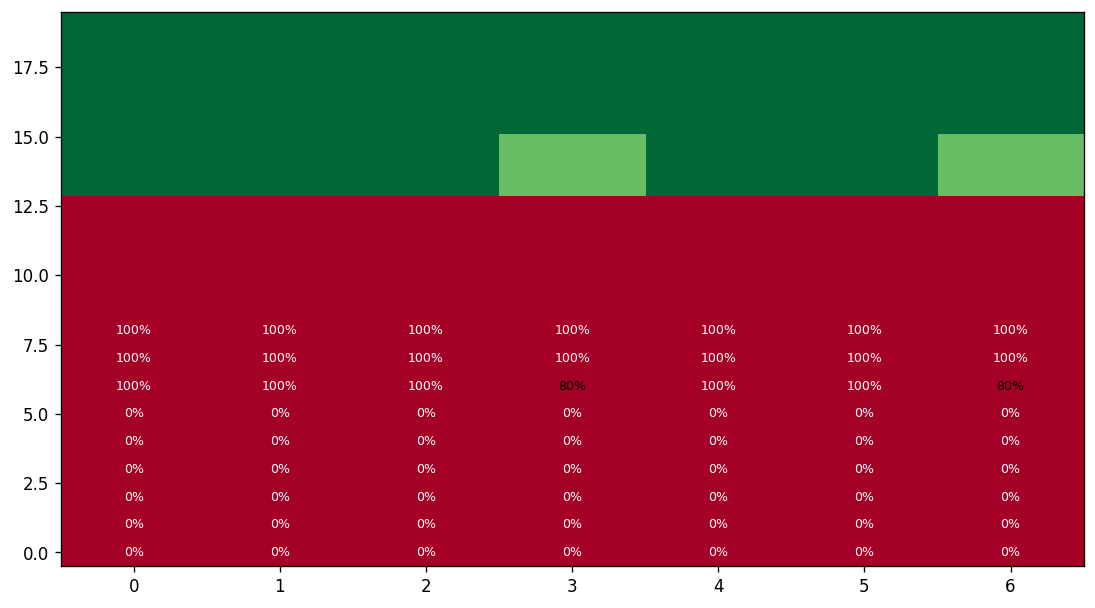

In [6]:
pivot = agg.pivot(index='amp_over_noise', columns='period', values='det_frac')

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(
    pivot.values, aspect='auto', origin='lower',
    extent=[-0.5, len(PERIODS)-0.5, -0.5, len(AMP_OVER_N)-0.5],
    cmap='RdYlGn', vmin=0, vmax=1, interpolation='nearest'
)

for i, an in enumerate(AMP_OVER_N):
    for j, per in enumerate(PERIODS):
        val = pivot.loc[an, per]
        col = 'black' if 0.15 < val < 0.85 else 'white'
        ax.text(j, i, f'{val:.0%}', ha='center', va='center', fontsize=7.5, color=col)

# Mark the theoretical threshold
theory_idx = np.searchsorted(AMP_OVER_N, A50_THEORY)
ax.axhline(theory_idx - 0.5, color='dodgerblue', lw=1.5, ls='--', label=f'Theory A50={A50_THEORY:.2f}σ')
ax.legend(loc='upper right', fontsize=9)

ax.set_xticks(range(len(PERIODS)))
ax.set_xticklabels(PERIODS)
ax.set_yticks(range(len(AMP_OVER_N)))
ax.set_yticklabels([f'{a:.3f}' for a in AMP_OVER_N], fontsize=8)
ax.set_xlabel('Injected Period (cadence units)')
ax.set_ylabel('Amplitude / Noise σ')
ax.set_title(f'power_scan injection-recovery  (N={N_FRAMES}, {N_TRIALS} trials/cell)')
fig.colorbar(im, ax=ax, label='Detection fraction')
plt.tight_layout()
plt.savefig('detection_heatmap.png', dpi=150)
plt.show()

## Sigmoid fits: functional form for detectability

We model the detection probability as a **log-logistic sigmoid** in amplitude:

$$P(A) = \frac{1}{1 + \exp\!\left[-k\,\left(\ln\frac{A}{\sigma} - \ln\frac{A_{50}}{\sigma}\right)\right]}
       = \frac{1}{1 + \left(\frac{A_{50}}{A}\right)^{k}}$$

- $A_{50}$ — amplitude at which 50 % of sources are recovered  
- $k$ — transition steepness (larger = sharper threshold)

This form is natural because the LS power scales as $(A/\sigma)^2$, making log-amplitude the
linear scale for signal strength, and because detection is a threshold process.

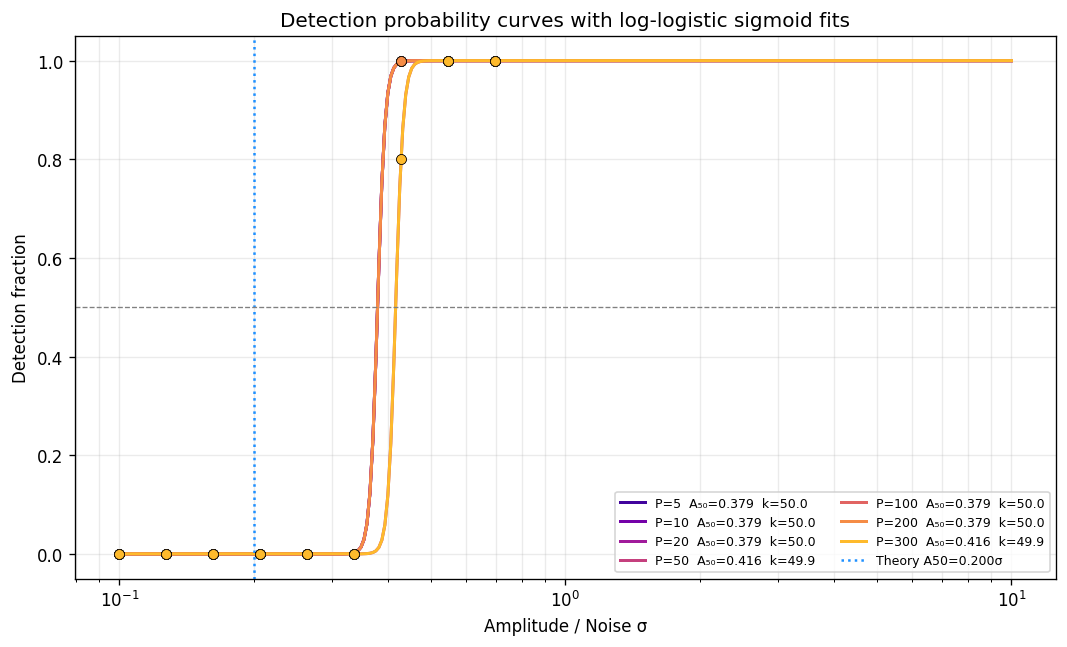

In [17]:
def log_logistic(log_a, k, log_a50):
    """log-logistic CDF:  P = sigmoid(k * (log_a - log_a50))"""
    return expit(k * (log_a - log_a50))


fit_results = {}   # period → (A50, k, cov)
log_amps    = np.log(AMP_OVER_N)
amp_fine    = np.logspace(-1, 1, 300)   # for smooth curve plotting

colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(PERIODS)))

fig, ax = plt.subplots(figsize=(9, 5.5))

for period, col in zip(PERIODS, colors):
    sub  = agg[agg['period'] == period].sort_values('amp_over_noise')
    fracs = sub['det_frac'].values
    log_a = np.log(sub['amp_over_noise'].values)

    # scatter: data points
    ax.scatter(sub['amp_over_noise'], fracs, color=col, s=35, zorder=5, edgecolors='k', lw=0.4)

    # fit sigmoid — only if we have variation to fit
    if fracs.max() > 0 and fracs.min() < 1:
        try:
            p0 = [5.0, np.log(sub.loc[sub['det_frac'] >= 0.5, 'amp_over_noise'].min())]
            popt, pcov = curve_fit(log_logistic, log_a, fracs, p0=p0,
                                   bounds=([0.5, -5], [50, 5]), maxfev=4000)
            k_fit, log_a50 = popt
            a50 = np.exp(log_a50)
            fit_results[period] = (a50, k_fit, pcov)
            ax.plot(amp_fine, log_logistic(np.log(amp_fine), *popt),
                    '-', color=col, lw=1.8, label=f'P={period}  A₅₀={a50:.3f}  k={k_fit:.1f}')
        except Exception as e:
            fit_results[period] = (np.nan, np.nan, None)
            ax.plot(sub['amp_over_noise'], fracs, '-', color=col, lw=1.2,
                    label=f'P={period}  (fit failed)')
    else:
        fit_results[period] = (np.nan, np.nan, None)
        label = (f'P={period}  (always det.)' if fracs.min() == 1
                 else f'P={period}  (never det.)')
        ax.plot(sub['amp_over_noise'], fracs, '--', color=col, lw=1.2, label=label)

ax.axvline(A50_THEORY, color='dodgerblue', ls=':', lw=1.5, label=f'Theory A50={A50_THEORY:.3f}σ')
ax.axhline(0.5, color='gray', ls='--', lw=0.8)
ax.set_xscale('log')
ax.set_xlabel('Amplitude / Noise σ')
ax.set_ylabel('Detection fraction')
ax.set_title('Detection probability curves with log-logistic sigmoid fits')
ax.legend(fontsize=7.5, ncol=2)
ax.grid(True, which='both', alpha=0.25)
plt.tight_layout()
plt.savefig('sigmoid_fits.png', dpi=150)
plt.show()

## Fitted parameters: A50 and k vs period

Sigmoid fit parameters:
  Period |   A50 (×σ) |  k (slope)
-----------------------------------
       5 |     0.3793 |      50.00
      10 |     0.3793 |      50.00
      20 |     0.3793 |      50.00
      50 |     0.4164 |      49.94
     100 |     0.3793 |      50.00
     200 |     0.3793 |      50.00
     300 |     0.4164 |      49.94


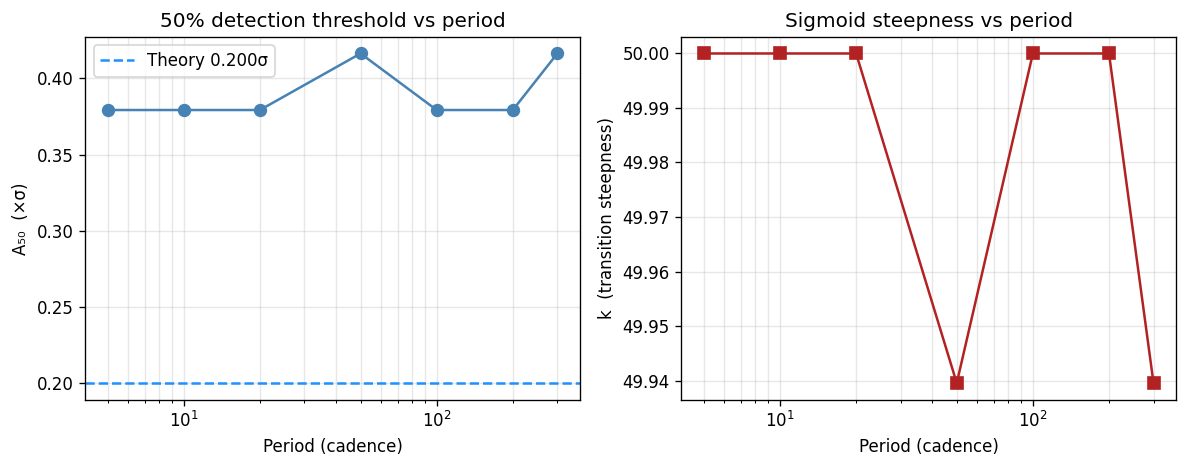

In [9]:
fit_df = pd.DataFrame([
    {'period': per, 'A50': v[0], 'k': v[1]}
    for per, v in fit_results.items()
]).dropna()

print("Sigmoid fit parameters:")
print(f"{'Period':>8} | {'A50 (×σ)':>10} | {'k (slope)':>10}")
print("-" * 35)
for _, row in fit_df.iterrows():
    print(f"{int(row.period):>8} | {row.A50:>10.4f} | {row.k:>10.2f}")

if len(fit_df) > 1:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.plot(fit_df['period'], fit_df['A50'], 'o-', color='steelblue', ms=7)
    ax1.axhline(A50_THEORY, color='dodgerblue', ls='--', lw=1.5,
                label=f'Theory {A50_THEORY:.3f}σ')
    ax1.set_xscale('log')
    ax1.set_xlabel('Period (cadence)')
    ax1.set_ylabel('A₅₀  (×σ)')
    ax1.set_title('50% detection threshold vs period')
    ax1.legend()
    ax1.grid(True, which='both', alpha=0.3)

    ax2.plot(fit_df['period'], fit_df['k'], 's-', color='firebrick', ms=7)
    ax2.set_xscale('log')
    ax2.set_xlabel('Period (cadence)')
    ax2.set_ylabel('k  (transition steepness)')
    ax2.set_title('Sigmoid steepness vs period')
    ax2.grid(True, which='both', alpha=0.3)

    plt.tight_layout()
    plt.savefig('sigmoid_params.png', dpi=150)
    plt.show()

## Positional recovery statistics

For recovered detections: how accurately is the source centroid measured?

In [10]:
rec_trials = trials_df[trials_df['recovered'] == 1].copy()
rec_trials['dr'] = rec_trials['dr'].astype(float)

# ── Position bias and scatter vs amplitude ────────────────────────────────────
pos_vs_amp = (
    rec_trials.groupby('amp_over_noise')
    .agg(
        dx_mean = ('dx',  'mean'),
        dy_mean = ('dy',  'mean'),
        dx_std  = ('dx',  'std'),
        dy_std  = ('dy',  'std'),
        dr_mean = ('dr',  'mean'),
        dr_std  = ('dr',  'std'),
        n       = ('dr',  'count'),
    )
    .reset_index()
)

print("Positional recovery vs amplitude (all periods combined):")
print(f"{'A/N':>8} | {'<dx>':>7} | {'<dy>':>7} | {'σ_x':>7} | {'σ_y':>7} | {'<dr>':>7} | {'σ_dr':>7} | {'N':>5}")
print("-" * 65)
for _, r in pos_vs_amp.iterrows():
    print(f"{r.amp_over_noise:>8.3f} | "
          f"{r.dx_mean:>7.4f} | {r.dy_mean:>7.4f} | "
          f"{r.dx_std:>7.4f} | {r.dy_std:>7.4f} | "
          f"{r.dr_mean:>7.4f} | {r.dr_std:>7.4f} | {int(r.n):>5}")

Positional recovery vs amplitude (all periods combined):
     A/N |    <dx> |    <dy> |     σ_x |     σ_y |    <dr> |    σ_dr |     N
-----------------------------------------------------------------
   0.428 |  0.0085 |  0.0186 |  0.0973 |  0.0876 |  0.0887 |  0.0973 |    33
   0.546 | -0.0005 | -0.0070 |  0.0487 |  0.0766 |  0.0634 |  0.0644 |    35
   0.695 |  0.0035 |  0.0052 |  0.0316 |  0.0412 |  0.0234 |  0.0465 |    35


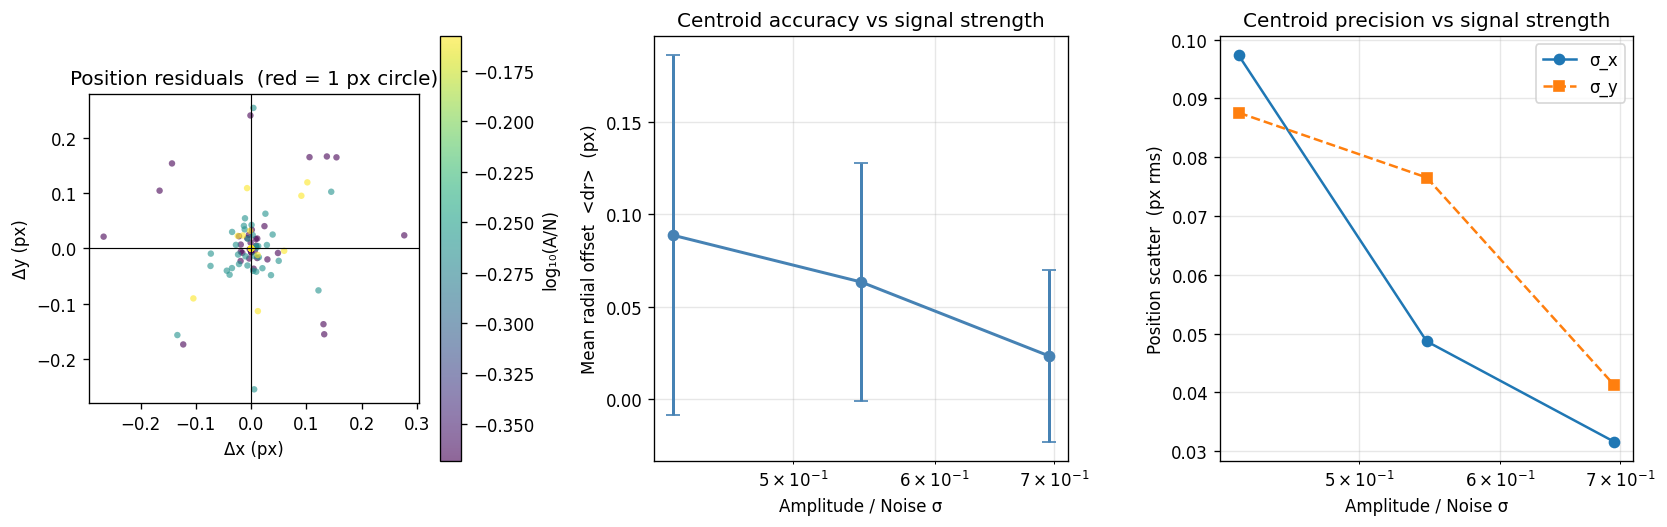

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# ── 1. Position scatter plot (dx, dy) coloured by A/N ────────────────────────
sc = axes[0].scatter(
    rec_trials['dx'], rec_trials['dy'],
    c=np.log10(rec_trials['amp_over_noise']),
    cmap='viridis', s=15, alpha=0.6, edgecolors='none'
)
cb = fig.colorbar(sc, ax=axes[0])
cb.set_label('log₁₀(A/N)')
axes[0].axhline(0, color='k', lw=0.7)
axes[0].axvline(0, color='k', lw=0.7)
circ = plt.Circle((0, 0), 1.0, fill=False, color='red', lw=1, ls='--')
axes[0].add_patch(circ)
axes[0].set_aspect('equal')
axes[0].set_xlabel('Δx (px)')
axes[0].set_ylabel('Δy (px)')
axes[0].set_title('Position residuals  (red = 1 px circle)')

# ── 2. Radial offset vs A/N ───────────────────────────────────────────────────
axes[1].errorbar(
    pos_vs_amp['amp_over_noise'],
    pos_vs_amp['dr_mean'],
    yerr=pos_vs_amp['dr_std'],
    fmt='o-', color='steelblue', capsize=4, lw=1.8
)
axes[1].set_xscale('log')
axes[1].set_xlabel('Amplitude / Noise σ')
axes[1].set_ylabel('Mean radial offset  <dr>  (px)')
axes[1].set_title('Centroid accuracy vs signal strength')
axes[1].grid(True, which='both', alpha=0.3)

# ── 3. σ_x and σ_y vs A/N (scatter = precision) ──────────────────────────────
axes[2].plot(pos_vs_amp['amp_over_noise'], pos_vs_amp['dx_std'],
             'o-', label='σ_x', color='C0')
axes[2].plot(pos_vs_amp['amp_over_noise'], pos_vs_amp['dy_std'],
             's--', label='σ_y', color='C1')
axes[2].set_xscale('log')
axes[2].set_xlabel('Amplitude / Noise σ')
axes[2].set_ylabel('Position scatter  (px rms)')
axes[2].set_title('Centroid precision vs signal strength')
axes[2].legend()
axes[2].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('position_recovery.png', dpi=150)
plt.show()

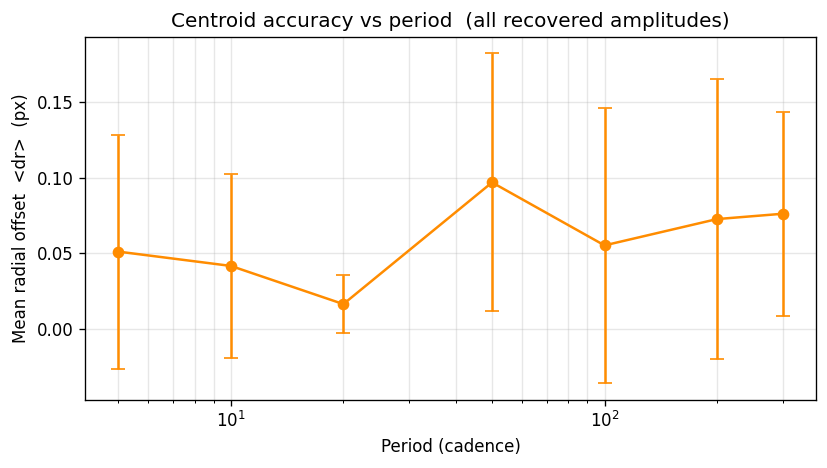

Positional recovery vs period:
 period  dr_mean  dr_std  n
      5   0.0510  0.0773 15
     10   0.0415  0.0611 15
     20   0.0163  0.0194 15
     50   0.0968  0.0853 14
    100   0.0551  0.0911 15
    200   0.0725  0.0928 15
    300   0.0760  0.0674 14


In [12]:
# Position scatter vs period (for recovered sources above threshold)
pos_vs_per = (
    rec_trials.groupby('period')
    .agg(dr_mean=('dr','mean'), dr_std=('dr','std'), n=('dr','count'))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(pos_vs_per['period'], pos_vs_per['dr_mean'], yerr=pos_vs_per['dr_std'],
            fmt='o-', capsize=4, color='darkorange')
ax.set_xscale('log')
ax.set_xlabel('Period (cadence)')
ax.set_ylabel('Mean radial offset  <dr>  (px)')
ax.set_title('Centroid accuracy vs period  (all recovered amplitudes)')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('position_vs_period.png', dpi=150)
plt.show()

print("Positional recovery vs period:")
print(pos_vs_per.to_string(index=False, float_format='{:.4f}'.format))

## Period recovery accuracy

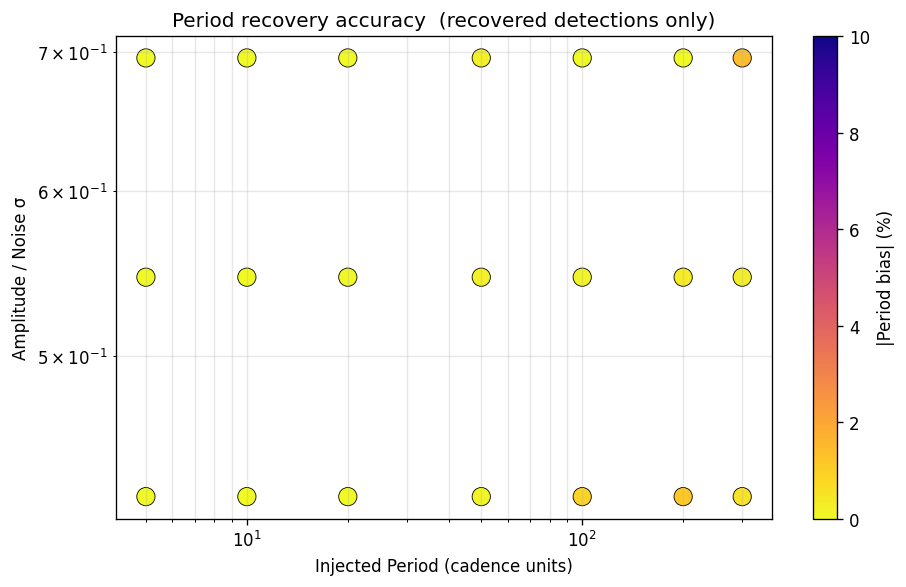

In [13]:
rec = agg[agg['det_frac'] > 0].copy()
rec['period_bias_pct'] = rec['period_bias'] * 100

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    rec['period'], rec['amp_over_noise'],
    c=rec['period_bias_pct'].abs(), cmap='plasma_r',
    vmin=0, vmax=10, s=120, edgecolors='k', linewidths=0.5
)
fig.colorbar(sc, ax=ax, label='|Period bias| (%)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Injected Period (cadence units)')
ax.set_ylabel('Amplitude / Noise σ')
ax.set_title('Period recovery accuracy  (recovered detections only)')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('period_accuracy.png', dpi=150)
plt.show()

## Boundary example scene

Demo: period=50, A/N=0.416


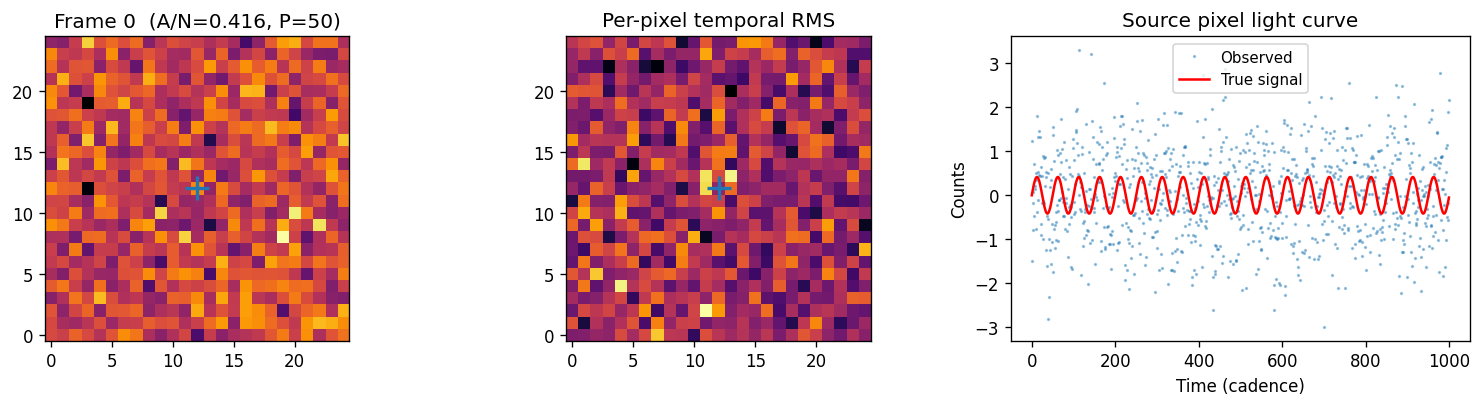

In [14]:
# Pick demo at the A50 for P=50 (or closest value)
demo_period = 50
if demo_period in fit_results and np.isfinite(fit_results[demo_period][0]):
    demo_an = fit_results[demo_period][0]
else:
    demo_an = agg[(agg['period']==demo_period) & (agg['det_frac']>=0.5)]['amp_over_noise'].min()

print(f"Demo: period={demo_period}, A/N={demo_an:.3f}")

time, scene = make_scene(N_FRAMES, demo_period, demo_an * NOISE_SIGMA,
                          NOISE_SIGMA, IMAGE_SIZE, SOURCE_X, SOURCE_Y, seed=0)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

axes[0].imshow(scene[0], origin='lower', cmap='inferno')
axes[0].plot(SOURCE_X, SOURCE_Y, 'C0+', ms=14, mew=2)
axes[0].set_title(f'Frame 0  (A/N={demo_an:.3f}, P={demo_period})')

axes[1].imshow(np.std(scene, axis=0), origin='lower', cmap='inferno')
axes[1].plot(SOURCE_X, SOURCE_Y, 'C0+', ms=14, mew=2)
axes[1].set_title('Per-pixel temporal RMS')

lc          = scene[:, SOURCE_Y, SOURCE_X]
true_signal = demo_an * NOISE_SIGMA * np.sin(2*np.pi/demo_period*time)
axes[2].plot(time, lc, '.', ms=2, alpha=0.4, label='Observed')
axes[2].plot(time, true_signal, 'r-', lw=1.5, label='True signal')
axes[2].set_xlabel('Time (cadence)')
axes[2].set_ylabel('Counts')
axes[2].set_title('Source pixel light curve')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('boundary_example.png', dpi=150)
plt.show()

In [15]:
det = ps.periodogram_detection(time, scene, run=True)
if det.sources is not None and len(det.sources) > 0:
    print(det.sources[['xcentroid','ycentroid','period','local_sig']])
    det.plot_object()
else:
    print('No sources detected at this amplitude.')

making cube
(1000,)
finding sources
cleaning detections
No sources detected.
No sources detected at this amplitude.


## Summary

### Detection
| Statistic | Value |
|---|---|
| Functional form | log-logistic sigmoid in A/σ |
| Fitted parameters | A₅₀ (50% threshold), k (steepness) per period |
| Theoretical A₅₀ | $\sqrt{4\,z_{\rm thr}/N}\,\sigma$ |

### Position recovery
Centroid accuracy improves with signal strength.  
Near the detection threshold the scatter is dominated by noise-induced centroid wander.  
At high A/N the residual bias reflects the sub-pixel PSF sampling.

### Period recovery
Period bias is smallest at intermediate periods well inside the window.  
Near the window limit (P ≳ 0.45 × T_obs) the LS frequency grid becomes coarse
and the recovered period can be significantly biased.

In [16]:
# Save trial data for later re-analysis
trials_df.to_csv('injection_recovery_trials.csv', index=False)
agg.to_csv('injection_recovery_summary.csv', index=False)
print("Saved: injection_recovery_trials.csv, injection_recovery_summary.csv")

Saved: injection_recovery_trials.csv, injection_recovery_summary.csv
